# Exercise Group - Chapter 3

Below you find exercises for Chapter 3. These exercises will prepare you in particular for the obligatory mid-term tests. The purpose of the prepared code snippets below is to give you some helpful structure for coding by predefining some useful variable names, but you do not need to use these prepared code snippets and prepared variable names if you do not want to. Do not hestitate to use the function `help()` to print the documentation of the functions that you need. If you are stuck, please ask one of the supervisors present.

<br>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import expon, norm

<br><br>

# Topic: Analysing the Heavy Tails of a Pareto Distribution

## Step 1: Generate and Visualise the Dataset

In a first step, we want to visually examine the difference between a heavy-tailed data set and a light-tailed data set. As an example of a heavy-tailed distribution, we will focus on the Pareto distribution, which is a special case of the generalised Pareto distribution introduced in the lecture. As an example of a light-tailed distribution, we will consider the exponential distribution.

**Task 1.1**: Use the function `np.random.pareto` to generate 2000 Pareto-distributed data points with shape parameter `a = 10`. Use the `numpy` seed 20 for reproducibility. This corresponds to a generalised Pareto distribution $G_{\gamma, \beta}$ as defined in 3.3.1 with parameters $\gamma = \beta = \frac{1}{a} = \frac{1}{10}$.

In [2]:
# Set parameters
np.random.seed(20)
sample_size = 2000
sample_mean = 10

In [3]:
data = np.random.pareto(a=sample_mean, size=sample_size)
data

array([0.09275819, 0.25608279, 0.24873225, ..., 0.18391877, 0.11797096,
       0.2199979 ])

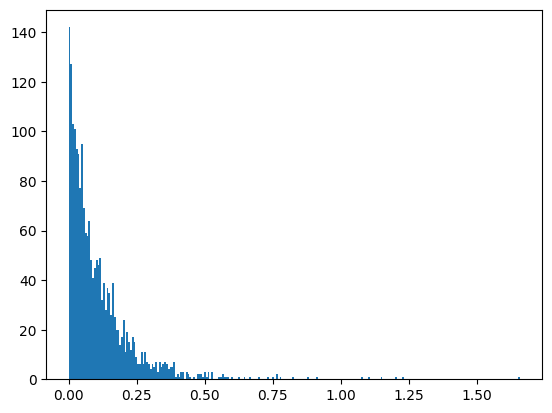

In [59]:
# Show data --> seem's "pareto-ish"
# plt.hist(data, bins=250)
# plt.show()

**Task 1.2**: Now, generate 2000 data points that are exponentially distributed with the same mean as your Pareto-distributed data above. Use the `np.random.exponential` function and again use the `numpy` seed 20 for reproducibility.

In [60]:
data_expon = np.random.exponential(scale=1/sample_mean, size=sample_size) # mean = 1/beta
data_expon

array([0.0436057 , 0.08503591, 0.05595655, ..., 0.19086868, 0.47918692,
       0.20523244])

In [6]:
# # Show data --> seem's "exponential-ish"
# plt.hist(data_expon, bins=250)
# plt.show()

**Task 1.3**: Use the `plt.subplots` method to plot your two datasets horizontally next to each other. Within the `plot` method, use the options `linestyle='-'` and `marker='o'`. What do you observe? What are the visual differences between a heavy-tailed and a light-tailed data set?

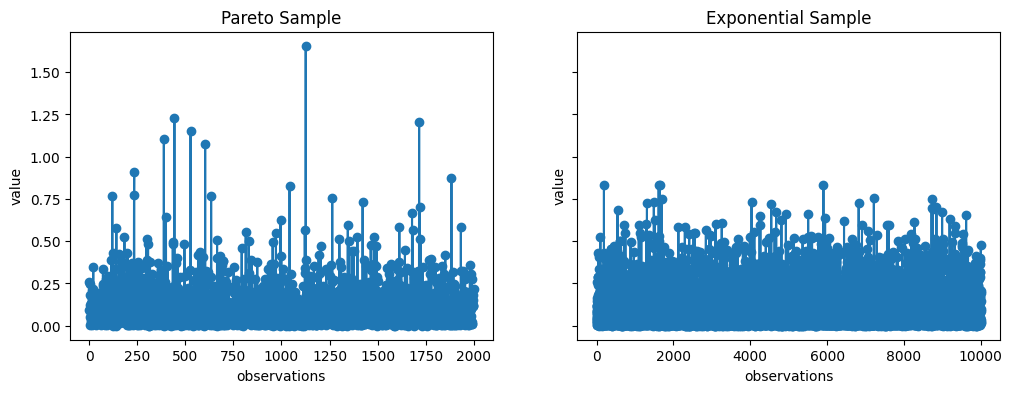

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Pareto sample
ax[0].plot(data, linestyle="-", marker="o")
ax[0].set_title("Pareto Sample")
ax[0].set_xlabel("observations")
ax[0].set_ylabel("value")

# Exponential sample
ax[1].plot(data_expon, linestyle="-", marker="o")
ax[1].set_title("Exponential Sample")
ax[1].set_xlabel("observations")
ax[1].set_ylabel("value")

plt.show()

In [8]:
# Answer:
# Pareto has much higher outlier values and also more outliers in general. Refers to the heavier tail shape of the distribution, so the mass under the tails of the dist is more than
# for the exponential dist.

<br>

## Step 2: Inspect a QQ plot

We now want to use a qq plot to compare the quantiles of the Pareto data set to quantiles of the exponential distribution. Quantiles of the exponential distribution can be obtained using the `expon.ppf` method from `scipy` (e.g. the command `expon.ppf(0.95, scale=1)` returns the 0.95 quantile of the $\mathrm{Exp}(1)$ distribution).

**Task 2.1**: First, we define some variables that will be useful for both the qq plot and the Hill plot in Step 3. Introduce a variable `n` that contains the number of data points in the Pareto data set. Then define an array `data_sorted`. This array should contain the data points $X_{1:n}, \dots, X_{n:n}$ in descending order.

*Useful Python commands*: `len`, `np.size`, `np.sort`

In [62]:
# Sample size
n = np.size(data) # size is counting number of elements (more flexible than len)

# Order statistic - empirical quantiles
data_sorted = np.sort(data)[::-1]

In [63]:
# Double check sorting
print(min(data), max(data))

2.0321794827360407e-05 1.6567524637460758


**Task 2.2**: Draw a qq plot of the Pareto data as in Section 3.1.2. As a reference distribution, use the exponential distribution with the same scale parameter as in Task 1.2. Your qq plot should also contain a straight line through the points $\{(x, x): x \in \mathbb{R}\}$. What can you observe? How can you identify from the qq plot whether your dataset has heavier tails than the reference distribution that you use?

*Useful Python commands*: `np.arange`, `np.linspace`, `np.mean`. The `alpha`-quantile of the exponential distribution with scale `lamb` can be accessed by the `scipy` command `expon(scale=lamb).ppf(points)`.

In [64]:
# Set parameters - [Ref. p33 - 3.1.2. qq plot, explaination]
lamb = 1 / sample_mean
# Eigentlich gemeint is lamb --> np.mean(data), empirischer Mean von 
# meinen daten und generiere dann meine exponential darum

In [65]:
### EXPONENTIAL (vectorized) - idea: give a vector and calc directly
k = np.arange(1, n+1)

exponential_quantiles_test = np.zeros(n)
exponential_quantiles_test = expon.ppf(scale=lamb, q=(n-k+1)/(n+1))

exponential_quantiles_test

array([7.60140233e-01, 6.90825515e-01, 6.50279005e-01, ...,
       1.50037538e-04, 1.00000008e-04, 4.99875042e-05])

In [66]:
### EXPONENTIAL
exponential_quantiles = np.zeros(n)

# Loop to fill values
for k in range(1, n): #k=1, ..., n
    exponential_quantiles[k-1] = expon.ppf(scale=lamb, q=(n-k+1)/(n+1))
    #important k-1, q=lower tail prob. - inside the formula

exponential_quantiles

array([7.60140233e-01, 6.90825515e-01, 6.50279005e-01, ...,
       1.50037538e-04, 1.00000008e-04, 0.00000000e+00])

In [67]:
### EMPIRICAL
data_sorted

array([1.65675246e+00, 1.22817075e+00, 1.20585432e+00, ...,
       5.24115951e-05, 4.54432682e-05, 2.03217948e-05])

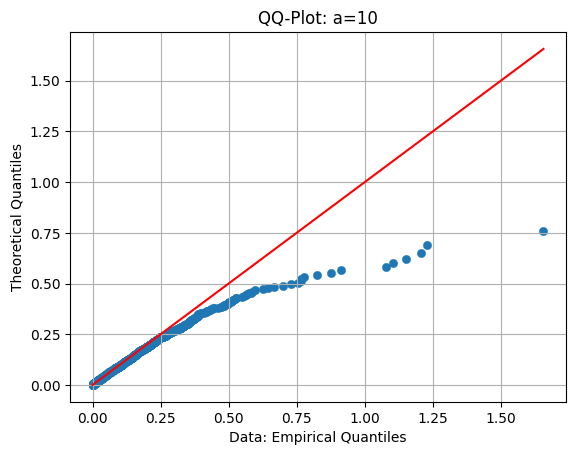

In [68]:
# Compare data
plt.scatter(data_sorted, exponential_quantiles, linewidth=0.3)
plt.plot(data_sorted, data_sorted, color="red") #x=x sind diesselben Werte

plt.title(f"QQ-Plot: a={sample_mean}")
plt.xlabel("Data: Empirical Quantiles")
plt.ylabel("Theoretical Quantiles")

plt.grid()
plt.show()

<br><br>

## Step 3: Create a Hill Plot

Since the Pareto distribution is a regularly varying distribution, one would like to estimate its index $\alpha$ of regular variation. One possibility to do so is the *Hill estimator* $\widehat \alpha_{k, n}^{(H)}$ with some number $k \in \{2, \dots, n\}$. In order to suitably choose $k$, we want to inspect a hill plot of the Pareto data set in the sense of Section 3.2.2. 

**Task 3.1**: If not already done in Task 2.1, introduce a variable `n` that contains the number of data points in the Pareto data set. Then define an array `data_sorted`. This array should contain the data points $X_{1:n}, \dots, X_{n:n}$ in descending order.

*Useful Python commands*: `len`, `np.size`, `np.sort`

In [16]:
# Prepare data
n = np.size(data)
data_sorted = np.sort(data)[::-1]

**Task 3.2**: Write a for-loop that iteratively computes the Hill estimator $\widehat \alpha_{k, n}^{(H)}$ for the Pareto data set for the different values $k \in \{2, \dots, n\}$. Store these different Hill estimates in an array `hill_estimators`. This array should accordingly have length $n - 1$.

*Useful Python commands*: `np.sum`, `np.log`

In [17]:
# Set up "parameters"
hill_estimator = np.zeros(n-1)

len(hill_estimator) #n-1

1999

In [18]:
# Test
for k in range(1, n):
    hill_estimator[k-1] = k
hill_estimator

array([1.000e+00, 2.000e+00, 3.000e+00, ..., 1.997e+03, 1.998e+03,
       1.999e+03])

In [19]:
# Test
3 / np.sum(np.log(data_sorted[:10]) - np.log(data_sorted[0]))

np.float64(-0.6658626626508598)

In [20]:
# Get hill estimator
for k in range(1, n):
    hill_estimator[k-1] = k / np.sum(np.log(data_sorted[:k]) - np.log(data_sorted[k]))

hill_estimator

array([3.3407557 , 5.95222834, 6.3592322 , ..., 0.14264387, 0.13986757,
       0.12577328])

**Task 3.3**: Draw the Hill plot as in Section 3.2.2. Interpret your Hill plot using a comment. How would you choose the number $k$? Does the Hill estimator provide a satisfying estimate of the index of regular variation of the Pareto distributed data?

In [21]:
# Remark:
# The first values are dominated by the variance so not good for any kind of use.
# Last values are dominated by bias, so take middle part.

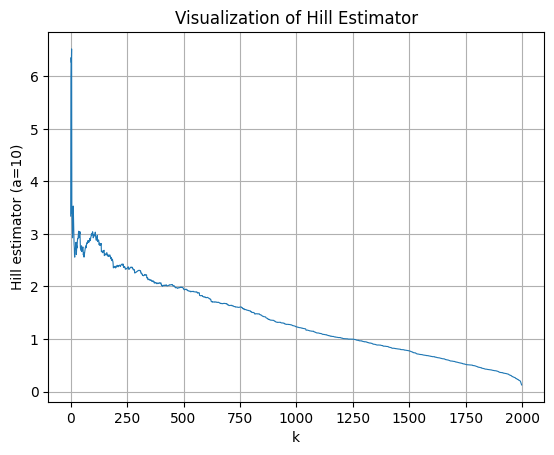

In [22]:
plt.plot(hill_estimator, linewidth=0.8)

plt.title("Visualization of Hill Estimator")
plt.xlabel("k")
plt.ylabel("Hill estimator (a=10)")

plt.grid()
plt.show()

In [23]:
# Answer:
# --> suggested estimator parameter is at 4 (real one is 10). So massively overestimating the risk
# --> heavier tails than there are really are

<br><br>

## Step 4: Create a Mean-Excess Plot

Another possibility to estimate the index of regular variation is the mean-excess plot in the sense of Section 3.3.3. Our goal is now to draw such a mean-excess plot for the Pareto data set.

**Task 4.1**: Define an array `u_arr`. This array should contain your Pareto distributed data points $X_{n:n}, \dots, X_{2:n}$ in **ascending order**. These will be the different thresholds $u$ used in the mean-excess plot.

*Useful Python commands*: `np.sort`

In [24]:
# Get pareto sample
sample_size = 10000
sample_mean = 10

pareto_sample = np.random.pareto(a=sample_mean, size=sample_size)

In [25]:
# Sort sample (ascending)
u_arr = np.sort(pareto_sample)[:-1] #kicked out last value (will be no higher value)

print(min(u_arr), max(u_arr))

1.3734830910161477e-05 1.4404984062322477


In [26]:
u_arr

array([1.37348309e-05, 2.69522957e-05, 3.18253538e-05, ...,
       1.29764832e+00, 1.40566862e+00, 1.44049841e+00])

**Task 4.2**: Now define an array `Nu_arr`. This array should have the same length as `u_arr` and for any threshold $u$ contained in the array `u_arr` it should contain the number of exceedences $N_{u} = |\{i \in \{1, \dots, n\}: X_i > u\}|$.

In [27]:
# Vector approach
Nu_arr = np.array([np.sum(pareto_sample > u) for u in u_arr])

In [28]:
# Loop approach
Nu_arr = np.zeros(len(u_arr))

# Get number of exceedences
for i in range(len(u_arr)):
    Nu_arr[i] = np.sum(pareto_sample > u_arr[i])
Nu_arr

array([9.999e+03, 9.998e+03, 9.997e+03, ..., 3.000e+00, 2.000e+00,
       1.000e+00])

**Task 4.3**: Use the arrays `u_arr` and `Nu_arr` defined above to compute the empirical mean excess function evaluated at the thresholds $X_{n:n}, \dots, X_{2:n}$ contained in the array `u_arr`. Store the mean excess function in an array `mean_excess` of the same length as `u_arr`. **--> so last values will be kicked out**

In [29]:
# Empirical mean excess
mean_excess = np.zeros(len(u_arr))

for i in range(len(mean_excess)):
    u = u_arr[i]
    mean_excess[i] = (1/Nu_arr[i]) * np.sum(pareto_sample[pareto_sample > u] - u)
mean_excess

array([0.11183291, 0.11183088, 0.11183719, ..., 0.20000921, 0.13798338,
       0.20630717])

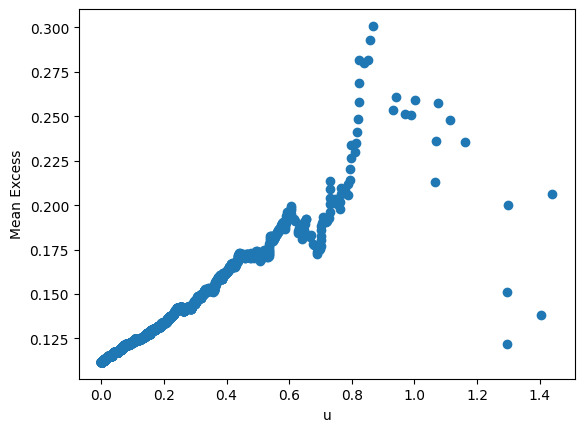

In [30]:
# Sense checking
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm, expon
from scipy.optimize import minimize

def MEF(x, u):
    assert u < max(x)
    mean_excess = (x[x > u] - u).mean()
    return mean_excess

def MEP(x):
    mes = []
    x = np.sort(x)
    for u in x[:-1]:
        mes.append(MEF(x, u))
    plt.scatter(x=x[:-1], y=mes)
    plt.xlabel("u")
    plt.ylabel("Mean Excess")

MEP(pareto_sample)

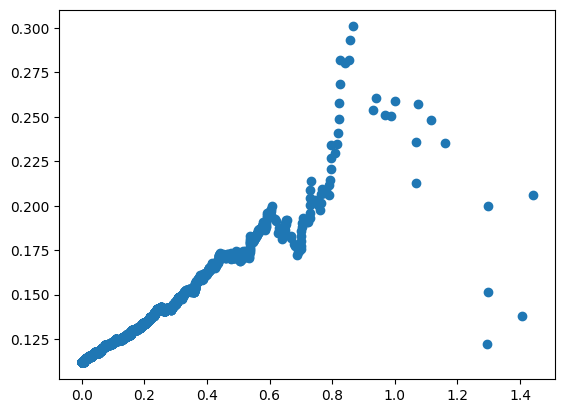

In [31]:
def MEF(x, u):
    if u >= np.max(x):
        print("MEF: u has to be smaller than the largest value of x.")
        sys.exit()
    y = x > u
    N_u = np.sum(y)
    e = 1 / N_u * np.dot((x - u), y)
    return e


def MEP(x):
    n = len(x)
    x = np.flip(np.sort(x))

    e = np.zeros(n - 1)
    for k in range(1, n):
        e[k - 1] = MEF(x, x[k])

    plt.plot(x[1:], e, "o")

MEP(pareto_sample)

In [32]:
# Theoretical mean excess
beta = 1 / sample_mean #beta=gamma, [Ref. 3.10]
gamma = beta

theo_mean_excess = (beta + gamma * u_arr) / (1-gamma)
theo_mean_excess

array([0.11111264, 0.11111411, 0.11111465, ..., 0.25529426, 0.26729651,
       0.27116649])

**Task 4.4**: Visualise the corresponding mean excess plot as in Section 3.3.3. Additionally, draw a straight line that corresponds to the theoretical mean excess function of the generalised Pareto distribution (see equation (3.10) in the lecture notes). Recall that the parameters $\gamma$ and $\beta$ of the $G_{\gamma, \beta}$ distribution corresponding to you Pareto distributed data are given by $\gamma = \beta = \frac{1}{10}$. Interpret your mean excess plot using a comment. In what range of thresholds $u$ does the empirical mean-excess function provide a reasonable estimate of the true mean-excess function?

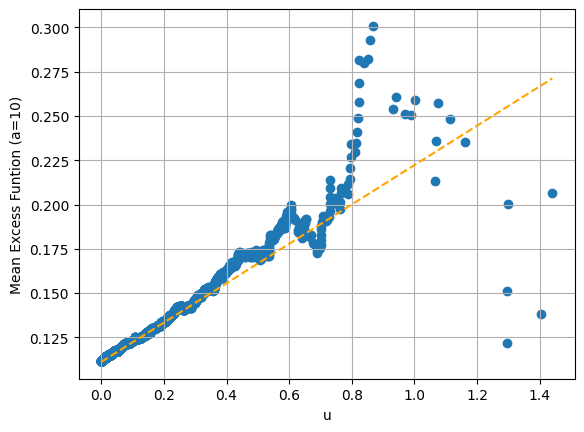

In [33]:
# Output data
plt.scatter(u_arr, mean_excess)
plt.plot(u_arr, theo_mean_excess, linestyle="--", color="orange")

plt.xlabel("u")
plt.ylabel("Mean Excess Funtion (a=10)")

plt.grid()
plt.show()

**Task 4.5**: Repeat the above steps, but instead of using the shape parameter `a=10` in Task 1.1, now use the shape parameter `a=2`. What can you observe?

<br><br>

# Topic: Assessing the Heavy Tails of the DAX Log-Returns

In Week 1, we visually examined the logarithmic returns of the DAX index and deduced that the assumption that DAX log-returns are iid normally distributed is not valid. We now want to back-up this finding by using a qq plot as well as the GARCH(1, 1) model.

In [34]:
dax_index = np.loadtxt('../shared_materials/data/DAX_index.csv', skiprows=1, usecols=[1], delimiter=',')
dax_returns = np.diff(np.log(dax_index))

## Step 1: Draw a QQ Plot of the DAX Returns Against the Normal Distribution

**Task 1.1**: Introduce a variable `n` that contains the number of DAX returns in the data set. Then define an array `dax_sorted`. This array should contain the data points DAX returns from the array `dax_returns` in descending order.

*Useful Python commands*: `len`, `np.size`, `np.sort`

In [35]:
n = len(dax_returns)
dax_sorted = np.sort(dax_returns)[::-1]

print(dax_sorted, n)

[ 0.10797465  0.10685088  0.10414289 ... -0.0827697  -0.08874672
 -0.1305486 ] 6309


In [36]:
# Sense check
print(max(dax_returns), min(dax_returns))

0.1079746549178413 -0.13054860415614833


**Task 1.2**: Draw a qq plot of the DAX returns as in Section 3.1.2. As a reference distribution, use the normal distribution with the same mean and same standard deviation as the DAX returns. Your qq plot should also contain a straight line through the points $\{(x, x): x \in \mathbb{R}\}$. What can you observe? What can you deduce about the tails of the distribution of the DAX returns?

*Useful Python commands*: The `alpha`-quantile of the $N(\mu, \sigma^2)$ distribution can be accessed by the `scipy` command `norm(loc=mu, scale=sigma).ppf(alpha)`.

In [37]:
# Set parameters
alpha = 0.95
mu = np.mean(dax_returns)
sigma = np.std(dax_returns)

k = np.arange(1, n+1)

In [38]:
### Normal distribution (vectorized)
normal_quantiles = norm(loc=mu, scale=sigma).ppf(q=(n-k+1)/(n+1))
normal_quantiles

array([ 0.05163236,  0.04899754,  0.04739687, ..., -0.04706266,
       -0.04866333, -0.05129815])

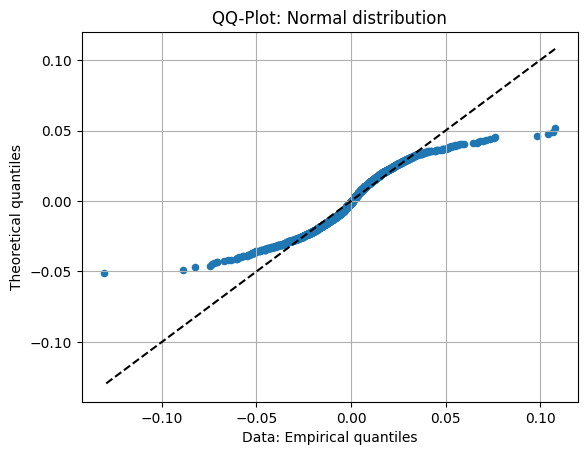

In [39]:
# QQ-Plot - Normal distribution
plt.scatter(dax_sorted, normal_quantiles, s=20)
plt.plot(dax_sorted, dax_sorted, linestyle="--", color="black")

plt.title("QQ-Plot: Normal distribution")
plt.xlabel("Data: Empirical quantiles")
plt.ylabel("Theoretical quantiles")

plt.grid()
plt.show()

<br><br>

## Step 2: Estimating the GARCH(1, 1) Parameters using Maximum-Likelihood Estimation

The following code snippet is used to estimate the parameters $\alpha_0, \alpha_1, \beta$ and $\sigma^2_0$ of the GARCH(1, 1) model using the method described in Example 2.7:

- First, we define a function `sigma_sq_from_data` that takes the log-returns $(X_n)_{n \in \{0, \dots, N\}}$ as an input variable `x`, which should be an array of length $N + 1$, followed by the parameters of the GARCH(1, 1) model. It returns the corresponding GARCH variance sequence $(\sigma^2_n)_{n \in \{0, \dots, N\}}$ computed by the recursion from Section 2.1.5.
- Second, we define a function `neg_log_lik_GARCH_11` which takes the parameter vector $\theta = (\alpha_0, \alpha_1, \beta, \sigma^2_0)$ and the array `x` of log-returns as input variables and returns the negative joint log-likelihood corresponding to the GARCH(1, 1) model as in Section 2.4 and Example 2.7.
- Finally, we define an initial guess of parameter values stored in an array `init` and then compute the Maximum-Likelihood estimates for the parameters by using the `scipy` function `minimize`.

In [40]:
def sigma_sq_from_data(x, alpha_0, alpha_1, beta, sigma_sq_0):
    n = np.size(x)
    sigma_sq = np.zeros(n)
    sigma_sq[0] = sigma_sq_0
    for i in range(1, n):
        sigma_sq[i] = alpha_0 + alpha_1 * x[i - 1] ** 2 + beta * sigma_sq[i - 1]
    return sigma_sq


def neg_log_lik_GARCH_11(theta, x):
    alpha_0, alpha_1, beta, sigma_sq_0 = theta
    n = np.size(x)
    
    sigma_sq = sigma_sq_from_data(x, alpha_0, alpha_1, beta, sigma_sq_0)

    return 0.5 * (x**2 / sigma_sq + np.log(2 * np.pi * sigma_sq)).sum()

    
init = np.array([0.01, 0.2, 0.8, np.var(dax_returns, ddof=1)])

alpha_0, alpha_1, beta, sigma_sq_0 = minimize(neg_log_lik_GARCH_11, args=dax_returns, x0=init, bounds=((1e-6, 5), (0, 5), (0, 1), (1e-6, 5))).x
print('The estimated parameters are alpha_0 = {:.3e}, alpha_1 = {:.5f}, beta = {:.5f}, sigma^2_0 = {:.5f}.'.format(alpha_0, alpha_1, beta, sigma_sq_0))

The estimated parameters are alpha_0 = 3.093e-06, alpha_1 = 0.10451, beta = 0.88060, sigma^2_0 = 0.00095.


## Step 3: Compare the DAX Returns with the Distribution of the Fitted GARCH(1, 1) Model

Using the fitted parameters from Step 2, we are now able to simulate a trajectory of the GARCH(1, 1) model. The simulations can afterwards be used to draw a qq plot of the DAX returns against the (unconditional) distribution of the fitted GARCH model.

**Task 3.1**: Simulate $m = 100\,000$ observations from the fitted GARCH(1, 1) model using the recursive formulas from Section 2.1.5. Use the command `np.random.seed(10)` for reproducibility. As an initial value $\sigma^2_0$ for the GARCH variance, use the sample variance of the DAX log-returns. Store your simulations in an array `sim_garch_X`.

*Useful Python commands*: `np.random.normal()`, `np.var`, `np.sqrt`

In [41]:
# Estimated parameters
print(alpha_0, alpha_1, beta, sigma_sq_0)

3.0931382523885754e-06 0.10450554349251946 0.8805973219751778 0.0009549199911561304


In [42]:
np.random.seed(10)

In [43]:
# Set parameters
m = 100000
sim_garch_sigma_sqn = np.zeros(m)
sim_garch_sigma_sqn[0] = np.sqrt(np.var(dax_returns))

sim_garch_X = np.zeros(m)
Yn = np.random.normal(loc=0, scale=1, size=m)

sim_garch_X[0] = Yn[0] * np.sqrt(sim_garch_sigma_sqn[0])

In [44]:
# Get simulated returns
for i in range(1, m):
    sim_garch_sigma_sqn[i] = alpha_0 + alpha_1*(sim_garch_X[i-1]**2) + beta*sim_garch_sigma_sqn[i-1]
    sim_garch_X[i] = np.sqrt(sim_garch_sigma_sqn[i]) * Yn[i]

In [45]:
print(sim_garch_sigma_sqn, sim_garch_X)

[0.01429181 0.01523671 0.01423517 ... 0.000245   0.00022005 0.00020921] [ 0.15918898  0.08829194 -0.18438361 ...  0.00340198 -0.01086863
  0.00584432]


**Task 3.2**: Use the function `np.quantile` to simultaneously compute the empirical quantiles at the levels $\frac{n - k + 1}{n + 1}$, $k \in \{1, \dots, n\}$ of your simulated GARCH(1, 1) observations stored in the array `sim_garch_X`. Store these quantiles in an array `garch_quantiles`.

In [46]:
# Set parameters
n = np.size(dax_returns)
k = np.arange(1, n+1)

In [47]:
# Get quantiles
garch_quantiles = np.quantile(a=sim_garch_X, q=(n-k+1)/(n+1))
garch_quantiles

array([ 0.11686535,  0.08983597,  0.081652  , ..., -0.08252013,
       -0.0946352 , -0.11011642])

**Task 3.3**: Draw a qq plot of the (sorted) DAX returns against the GARCH(1, 1) quantiles stored in the array `garch_quantiles`. Compare your qq plot to the qq plot from Task 1.2.

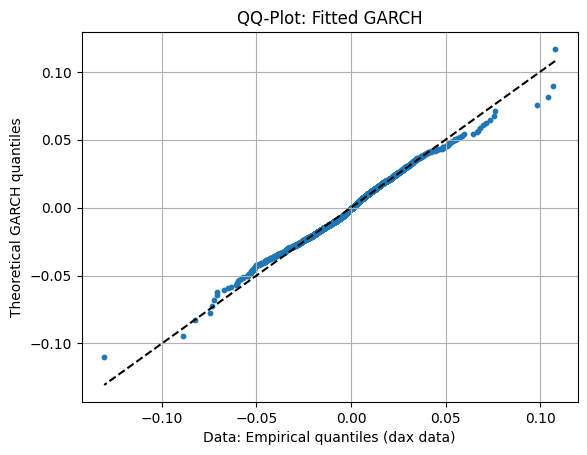

In [48]:
# QQ-Plot - Fitted GARCH Vola
plt.scatter(dax_sorted, garch_quantiles, s=10)
plt.plot(dax_sorted, dax_sorted, linestyle="--", color="black")

plt.title("QQ-Plot: Fitted GARCH")
plt.xlabel("Data: Empirical quantiles (dax data)")
plt.ylabel("Theoretical GARCH quantiles")

plt.grid()
plt.show()

## Peak over threshold (POT) method and other resourcess
Here are all the additional codes for the mid-term exam:

Pseudo Code for the method: (p.40)
1. Determine u by e.g. mean-excess plot --> determine which obs are above u (only take those)
2. Calculate Y = Xj - u, all exceeding parts
3. Minimize negative lik. function --> beta_hat and gamma_hat
4. Determine pareto law (3.11)
5. Estimate VaR (3.12)
6. Estimate ES (3.13)

#### 1. Create sample and prepare data

In [49]:
# Create a dummy sample
np.random.seed(20)
sample_size = 10000
sample_mean = 10

pareto_sample = np.random.pareto(a=sample_mean, size=sample_size)

In [50]:
# Sort sample
u_arr = np.sort(pareto_sample)[:-1] #asending and last value kicked out

In [51]:
# Get exceedences
excess = np.zeros(len(u_arr))

for i in range(len(excess)):
    u = u_arr[i]
    excess[i] = np.sum(pareto_sample[pareto_sample > u] - u)

#### 2. Minimize LL-Function (Estimate parameters)

In [52]:
y = pareto_sample[pareto_sample > 0.1] - 0.1
y

array([0.15608279, 0.14873225, 0.08434948, ..., 0.03323513, 0.21143001,
       0.04123322])

In [53]:
# From Mean excess plot (result)
u = 0.1
theta = np.array([0.1, 0.1])
pareto_sample = np.array(pareto_sample)

In [54]:
# LL-function
def neg_log_lik_pot(theta, sample, u):
    y = sample[sample > u] - u
    Nu = np.size(y)
    beta, gamma = theta
    
    return + Nu * np.log(beta) - ((1/gamma)+1) * np.sum(np.log(1+ (gamma/beta)*y)) # In order to minimize the "-" is a plus

In [55]:
# Test function
neg_log_lik_pot(theta, pareto_sample, 0.1)

np.float64(-13936.274534855824)

In [56]:
# Minimizing LL-function
init = np.array([1, 1])

beta_hat, gamma_hat = minimize(neg_log_lik_pot, args=(pareto_sample, u), x0=init, bounds=((0, np.inf), (0, np.inf))).x

/tmp/ipykernel_91/2869130652.py:7: RuntimeWarning: divide by zero encountered in log
  return + Nu * np.log(beta) - ((1/gamma)+1) * np.sum(np.log(1+ (gamma/beta)*y)) # In order to minimize the "-" is a plus
/tmp/ipykernel_91/2869130652.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  return + Nu * np.log(beta) - ((1/gamma)+1) * np.sum(np.log(1+ (gamma/beta)*y)) # In order to minimize the "-" is a plus
/usr/local/lib/python3.10/dist-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [57]:
print(beta_hat, gamma_hat)

0.9971157179017844 1.999995840449738


#### 3. Calculate tail-cdf and risk measures

In [58]:
# # # Tail cdf - x=point above u (in range), n is the sample size
F_hat = Nu/n * (1+ (gamma_hat*x)/beta_hat)**-1/gamma_hat

NameError: name 'Nu' is not defined

In [ ]:
# Get estimated VaR


In [ ]:
# Get estimated ES


In [ ]:
# Emotional hedge
def PoT_estimated(x, u):
    y = x[x > u] - u # excesses
    N_u = len(y)
    def neg_ll(theta):
        beta, gamma = theta
        return + N_u * np.log(beta) - (1/gamma +1) * np.log(1 + gamma/beta*y).sum()
    res = minimize(neg_ll, x0=(1,1), bounds=((0.01, np.inf), (0.01, np.inf)), method="Nelder-Mead", options={"disp":True})
    beta_hat, gamma_hat = res.x
    return beta_hat, gamma_hat


def VaR_ES_PoT(x, p, u):
    n = len(x)
    N_u = len(x[x > u])
    beta, gamma = PoT_estimated(x, u)
    var = u + beta * ((n/N_u*(1-p))**(-gamma)-1)
    es = var + (beta + gamma*(var - u))/(1 - gamma)
    return var, es